# Questão 1(a) - HOG + SVM

Classificação binária de imagens usando o dataset `PetImages/` (`Cat` vs `Dog`).

Este notebook faz:

- validação e remoção de imagens corrompidas;
- divisão holdout com 70% treino e 30% teste;
- pré-processamento com resize para `224x224`, preservação opcional da proporção, escala de cinza e CLAHE;
- extração de descritores HOG com OpenCV;
- treinamento de um SVM linear com OpenCV;
- avaliação com acurácia, F1-score, matriz de confusão, relatório de classificação e exemplos de acerto/erro.

## 0. Dependências

Execute esta célula antes dos imports. Ela instala apenas pacotes ausentes no kernel atual.

In [5]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "cv2": "opencv-python",
    "sklearn": "scikit-learn",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "tqdm": "tqdm",
}

missing = [package for module, package in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]

if missing:
    print("Instalando dependências ausentes:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("Dependências já instaladas.")

Dependências já instaladas.


## 1. Imports

In [6]:
from pathlib import Path
import math
import random
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)

## 2. Configuração

In [7]:
DATA_DIR = Path("PetImages")
OUTPUT_DIR = Path("outputs/partA")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_TO_LABEL = {"Cat": 0, "Dog": 1}
LABEL_TO_CLASS = {label: name for name, label in CLASS_TO_LABEL.items()}
CLASS_NAMES = ["Cat", "Dog"]

RANDOM_STATE = 42
TEST_SIZE = 0.30
IMG_SIZE = (224, 224)  # OpenCV usa formato (largura, altura) no resize
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

# Use None para dataset inteiro. Se ficar lento ou faltar memória, teste 2000 ou 4000 por classe.
MAX_IMAGES_PER_CLASS = None

# Tweaks úteis para melhorar acurácia/F1 sem mexer no conjunto de teste.
USE_ASPECT_RATIO_PADDING = True  # evita distorcer gatos/cachorros no resize 224x224
USE_CLAHE = True                 # contraste local costuma ser melhor que equalização global
APPLY_HIST_EQUALIZATION = False  # fallback se USE_CLAHE=False

# 'balanced' roda melhor. 'detailed' tende a melhorar, mas usa mais RAM/tempo.
HOG_PRESET = "balanced"  # opções: 'balanced' ou 'detailed'

TUNE_SVM_C = True
VALIDATION_SIZE = 0.20
SVM_C_VALUES = [0.01, 0.1, 1.0, 10.0]
SVM_C = 1.0  # usado se TUNE_SVM_C=False

print(f"Dataset: {DATA_DIR.resolve()}")
print(f"Saídas: {OUTPUT_DIR.resolve()}")

Dataset: /home/gui/Documents/code/vc/ListaVisao-2026.1/Lista_04/PetImages
Saídas: /home/gui/Documents/code/vc/ListaVisao-2026.1/Lista_04/outputs/partA


## 3. Validação das imagens

O dataset `PetImages` costuma ter alguns arquivos JPEG quebrados. Esta etapa mantém apenas imagens que o OpenCV consegue abrir.

In [8]:
def collect_valid_images(data_dir, class_to_label, max_images_per_class=None):
    rows = []
    bad_paths = []
    rng = np.random.default_rng(RANDOM_STATE)

    for class_name, label in class_to_label.items():
        class_dir = data_dir / class_name
        if not class_dir.exists():
            raise FileNotFoundError(f"Pasta não encontrada: {class_dir}")

        candidates = sorted(
            path for path in class_dir.iterdir()
            if path.is_file() and path.suffix.lower() in VALID_EXTENSIONS
        )

        valid_paths = []
        for path in tqdm(candidates, desc=f"Validando {class_name}"):
            image = cv2.imread(str(path))
            if image is None:
                bad_paths.append(path)
                continue
            valid_paths.append(path)

        if max_images_per_class is not None and len(valid_paths) > max_images_per_class:
            valid_paths = list(rng.choice(valid_paths, size=max_images_per_class, replace=False))

        rows.extend(
            {"path": str(path), "label": label, "class_name": class_name}
            for path in valid_paths
        )

    return pd.DataFrame(rows), bad_paths

df, bad_paths = collect_valid_images(DATA_DIR, CLASS_TO_LABEL, MAX_IMAGES_PER_CLASS)

if bad_paths:
    (OUTPUT_DIR / "bad_images.txt").write_text(
        "\n".join(str(path) for path in bad_paths),
        encoding="utf-8",
    )

print(f"Imagens válidas: {len(df)}")
print(f"Imagens corrompidas/ilegíveis: {len(bad_paths)}")
display(df["class_name"].value_counts().reindex(CLASS_NAMES).to_frame("quantidade"))
df.head()

Validando Dog: 100%|██████████| 12499/12499 [00:06<00:00, 1857.80it/s]

Imagens válidas: 24997
Imagens corrompidas/ilegíveis: 1


,quantidade
class_name,
Cat,12498
Dog,12499


,path,label,class_name
0,PetImages/Cat/0.jpg,0,Cat
1,PetImages/Cat/1.jpg,0,Cat
2,PetImages/Cat/10.jpg,0,Cat
3,PetImages/Cat/100.jpg,0,Cat
4,PetImages/Cat/1000.jpg,0,Cat


## 4. Split holdout 70/30

In [9]:
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df["label"],
    random_state=RANDOM_STATE,
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_summary = pd.DataFrame({
    "treino": train_df["class_name"].value_counts().reindex(CLASS_NAMES),
    "teste": test_df["class_name"].value_counts().reindex(CLASS_NAMES),
})

print(f"Treino: {len(train_df)} imagens ({len(train_df) / len(df):.1%})")
print(f"Teste: {len(test_df)} imagens ({len(test_df) / len(df):.1%})")
display(split_summary)

Treino: 17497 imagens (70.0%)
Teste: 7500 imagens (30.0%)


,treino,teste
class_name,,
Cat,8748,3750
Dog,8749,3750


## 5. Amostras do dataset

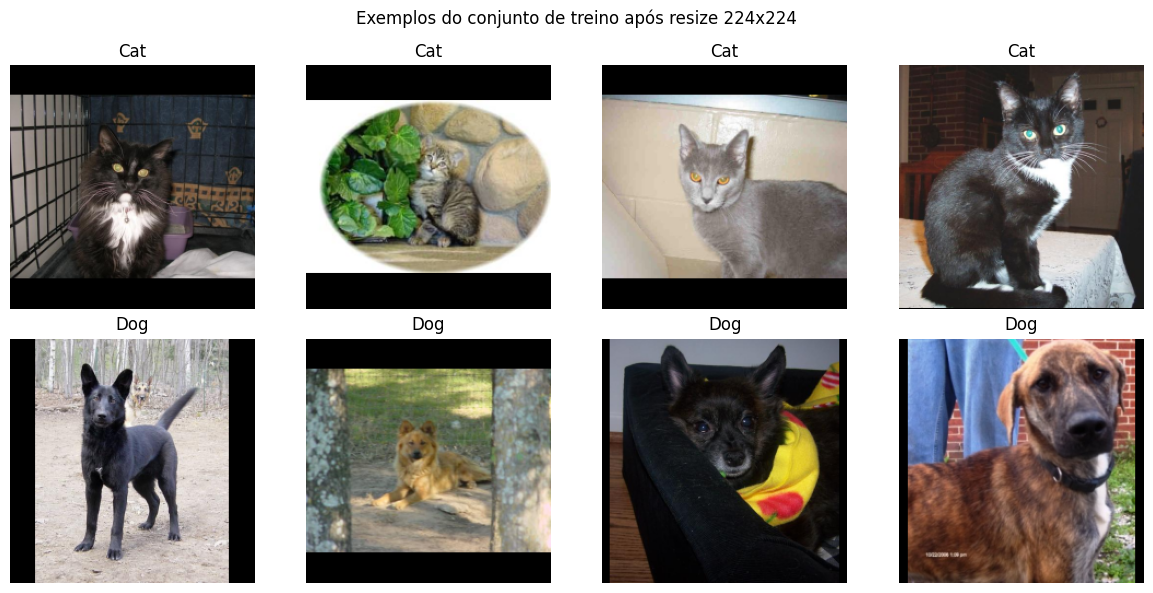

In [10]:
def resize_to_square(image, img_size=IMG_SIZE, pad_color=0):
    target_w, target_h = img_size
    h, w = image.shape[:2]
    scale = min(target_w / w, target_h / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC
    resized = cv2.resize(image, (new_w, new_h), interpolation=interpolation)

    if image.ndim == 2:
        canvas = np.full((target_h, target_w), pad_color, dtype=image.dtype)
    else:
        canvas = np.full((target_h, target_w, image.shape[2]), pad_color, dtype=image.dtype)

    x0 = (target_w - new_w) // 2
    y0 = (target_h - new_h) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
    return canvas

def resize_for_model(image, img_size=IMG_SIZE):
    if USE_ASPECT_RATIO_PADDING:
        return resize_to_square(image, img_size=img_size, pad_color=0)
    return cv2.resize(image, img_size, interpolation=cv2.INTER_AREA)

def load_rgb_resized(path, img_size=IMG_SIZE):
    image = cv2.imread(str(path))
    if image is None:
        raise ValueError(f"Imagem ilegível: {path}")
    image = resize_for_model(image, img_size=img_size)
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

sample_parts = []
for class_name in CLASS_NAMES:
    group = train_df[train_df["class_name"] == class_name]
    if len(group):
        sample_parts.append(group.sample(min(4, len(group)), random_state=RANDOM_STATE))

sample_df = pd.concat(sample_parts).reset_index(drop=True)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, (_, row) in zip(axes.ravel(), sample_df.iterrows()):
    ax.imshow(load_rgb_resized(row["path"]))
    ax.set_title(row["class_name"])
    ax.axis("off")

for ax in axes.ravel()[len(sample_df):]:
    ax.axis("off")

fig.suptitle("Exemplos do conjunto de treino após resize 224x224")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dataset_examples.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Pré-processamento e HOG

Parâmetros HOG usados via `HOG_PRESET`:

- janela: `224x224`;
- `balanced`: bloco `32x32`, stride `16x16`, célula `16x16`;
- `detailed`: bloco `16x16`, stride `8x8`, célula `8x8`;
- bins de orientação: `9`.

O preset `detailed` pode melhorar acurácia/F1, mas aumenta bastante RAM e tempo de treino.

In [11]:
HOG_CONFIGS = {
    "balanced": {
        "block_size": (32, 32),
        "block_stride": (16, 16),
        "cell_size": (16, 16),
    },
    "detailed": {
        "block_size": (16, 16),
        "block_stride": (8, 8),
        "cell_size": (8, 8),
    },
}

if HOG_PRESET not in HOG_CONFIGS:
    raise ValueError(f"HOG_PRESET inválido: {HOG_PRESET}")

hog_config = HOG_CONFIGS[HOG_PRESET]
HOG_WIN_SIZE = IMG_SIZE
HOG_BLOCK_SIZE = hog_config["block_size"]
HOG_BLOCK_STRIDE = hog_config["block_stride"]
HOG_CELL_SIZE = hog_config["cell_size"]
HOG_NBINS = 9

hog = cv2.HOGDescriptor(
    HOG_WIN_SIZE,
    HOG_BLOCK_SIZE,
    HOG_BLOCK_STRIDE,
    HOG_CELL_SIZE,
    HOG_NBINS,
)

print(f"Preset HOG: {HOG_PRESET}")
print(f"block={HOG_BLOCK_SIZE}, stride={HOG_BLOCK_STRIDE}, cell={HOG_CELL_SIZE}")
print(f"Tamanho do descriptor HOG: {hog.getDescriptorSize()}")

Preset HOG: balanced
block=(32, 32), stride=(16, 16), cell=(16, 16)
Tamanho do descriptor HOG: 6084


In [12]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def preprocess_for_hog(path):
    image = cv2.imread(str(path))
    if image is None:
        raise ValueError(f"Imagem ilegível durante extração HOG: {path}")

    image = resize_for_model(image, img_size=IMG_SIZE)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    if USE_CLAHE:
        gray = clahe.apply(gray)
    elif APPLY_HIST_EQUALIZATION:
        gray = cv2.equalizeHist(gray)

    return gray

def extract_hog_matrix(paths, descriptor):
    feature_size = descriptor.getDescriptorSize()
    features = np.empty((len(paths), feature_size), dtype=np.float32)

    for idx, path in enumerate(tqdm(paths, desc="Extraindo HOG")):
        gray = preprocess_for_hog(path)
        features[idx] = descriptor.compute(gray).reshape(-1).astype(np.float32)

    return features

X_train = extract_hog_matrix(train_df["path"].tolist(), hog)
y_train = train_df["label"].to_numpy(dtype=np.int32)

X_test = extract_hog_matrix(test_df["path"].tolist(), hog)
y_test = test_df["label"].to_numpy(dtype=np.int32)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test: {X_test.shape} | y_test: {y_test.shape}")

Extraindo HOG: 100%|██████████| 7500/7500 [00:11<00:00, 625.37it/s]

X_train: (17497, 6084) | y_train: (17497,)
X_test: (7500, 6084) | y_test: (7500,)


## 7. Treinamento do SVM com OpenCV

In [13]:
def create_linear_svm(c):
    model = cv2.ml.SVM_create()
    model.setType(cv2.ml.SVM_C_SVC)
    model.setKernel(cv2.ml.SVM_LINEAR)
    model.setC(float(c))
    model.setTermCriteria((cv2.TERM_CRITERIA_MAX_ITER + cv2.TERM_CRITERIA_EPS, 5000, 1e-6))
    return model

def predict_svm(model, features):
    _, pred = model.predict(features)
    return pred.reshape(-1).astype(int)

if TUNE_SVM_C:
    tune_train_idx, tune_val_idx = train_test_split(
        np.arange(len(y_train)),
        test_size=VALIDATION_SIZE,
        stratify=y_train,
        random_state=RANDOM_STATE,
    )

    tuning_rows = []
    for c in SVM_C_VALUES:
        print(f"Validando C={c}...")
        candidate = create_linear_svm(c)
        candidate.train(X_train[tune_train_idx], cv2.ml.ROW_SAMPLE, y_train[tune_train_idx])
        val_pred = predict_svm(candidate, X_train[tune_val_idx])
        tuning_rows.append({
            "C": c,
            "val_accuracy": accuracy_score(y_train[tune_val_idx], val_pred),
            "val_macro_f1": f1_score(y_train[tune_val_idx], val_pred, average="macro"),
            "val_weighted_f1": f1_score(y_train[tune_val_idx], val_pred, average="weighted"),
        })

    tuning_df = pd.DataFrame(tuning_rows).sort_values(
        ["val_macro_f1", "val_accuracy"],
        ascending=False,
    )
    tuning_df.to_csv(OUTPUT_DIR / "svm_c_tuning.csv", index=False)
    SVM_C = float(tuning_df.iloc[0]["C"])
    display(tuning_df)
    print(f"Melhor C escolhido no treino/validação: {SVM_C}")

svm = create_linear_svm(SVM_C)
print(f"Treinando SVM linear final com C={SVM_C}...")
svm.train(X_train, cv2.ml.ROW_SAMPLE, y_train)
svm.save(str(OUTPUT_DIR / "hog_svm_opencv.xml"))
print("Modelo salvo em:", OUTPUT_DIR / "hog_svm_opencv.xml")

Validando C=0.01...
Validando C=0.1...
Validando C=1.0...
Validando C=10.0...


,C,val_accuracy,val_macro_f1,val_weighted_f1
0,0.01,0.755143,0.755112,0.755112
2,1.00,0.635429,0.634566,0.634566
3,10.00,0.635429,0.634566,0.634566
1,0.10,0.541714,0.540579,0.540579


Melhor C escolhido no treino/validação: 0.01
Treinando SVM linear final com C=0.01...
Modelo salvo em: outputs/partA/hog_svm_opencv.xml


## 8. Avaliação

In [14]:
train_pred = predict_svm(svm, X_train)
test_pred = predict_svm(svm, X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)
test_macro_f1 = f1_score(y_test, test_pred, average="macro")
test_weighted_f1 = f1_score(y_test, test_pred, average="weighted")

print(f"Acurácia no treino: {train_accuracy:.4f}")
print(f"Acurácia no teste: {test_accuracy:.4f}")
print(f"F1 macro no teste: {test_macro_f1:.4f}")
print(f"F1 weighted no teste: {test_weighted_f1:.4f}")

report = classification_report(
    y_test,
    test_pred,
    target_names=CLASS_NAMES,
    digits=4,
)
print(report)

metrics_df = pd.DataFrame([
    {
        "model": "OpenCV HOG + linear SVM",
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "test_macro_f1": test_macro_f1,
        "test_weighted_f1": test_weighted_f1,
        "train_size": len(train_df),
        "test_size": len(test_df),
        "svm_c": SVM_C,
        "svm_c_tuned": TUNE_SVM_C,
        "hog_preset": HOG_PRESET,
        "hog_block_size": str(HOG_BLOCK_SIZE),
        "hog_block_stride": str(HOG_BLOCK_STRIDE),
        "hog_cell_size": str(HOG_CELL_SIZE),
        "hog_descriptor_size": hog.getDescriptorSize(),
        "image_size": f"{IMG_SIZE[0]}x{IMG_SIZE[1]}",
        "aspect_ratio_padding": USE_ASPECT_RATIO_PADDING,
        "clahe": USE_CLAHE,
    }
])

metrics_df.to_csv(OUTPUT_DIR / "metrics_hog_svm.csv", index=False)
(OUTPUT_DIR / "classification_report_hog_svm.txt").write_text(report, encoding="utf-8")
metrics_df

Acurácia no treino: 0.7802
Acurácia no teste: 0.7531
F1 macro no teste: 0.7529
F1 weighted no teste: 0.7529
              precision    recall  f1-score   support

         Cat     0.7395    0.7813    0.7599      3750
         Dog     0.7682    0.7248    0.7459      3750

    accuracy                         0.7531      7500
   macro avg     0.7539    0.7531    0.7529      7500
weighted avg     0.7539    0.7531    0.7529      7500



,model,train_accuracy,test_accuracy,test_macro_f1,test_weighted_f1,train_size,test_size,svm_c,svm_c_tuned,hog_preset,hog_block_size,hog_block_stride,hog_cell_size,hog_descriptor_size,image_size,aspect_ratio_padding,clahe
0,OpenCV HOG + linear SVM,0.780191,0.753067,0.752869,0.752869,17497,7500,0.01,True,balanced,"(32, 32)","(16, 16)","(16, 16)",6084,224x224,True,True


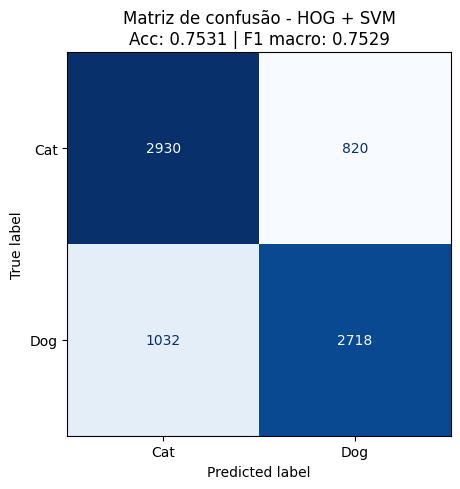

In [15]:
cm = confusion_matrix(y_test, test_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)
ax.set_title(f"Matriz de confusão - HOG + SVM\nAcc: {test_accuracy:.4f} | F1 macro: {test_macro_f1:.4f}")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "confusion_matrix_hog_svm.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(OUTPUT_DIR / "confusion_matrix_hog_svm.csv")

## 9. Exemplos de acerto e erro

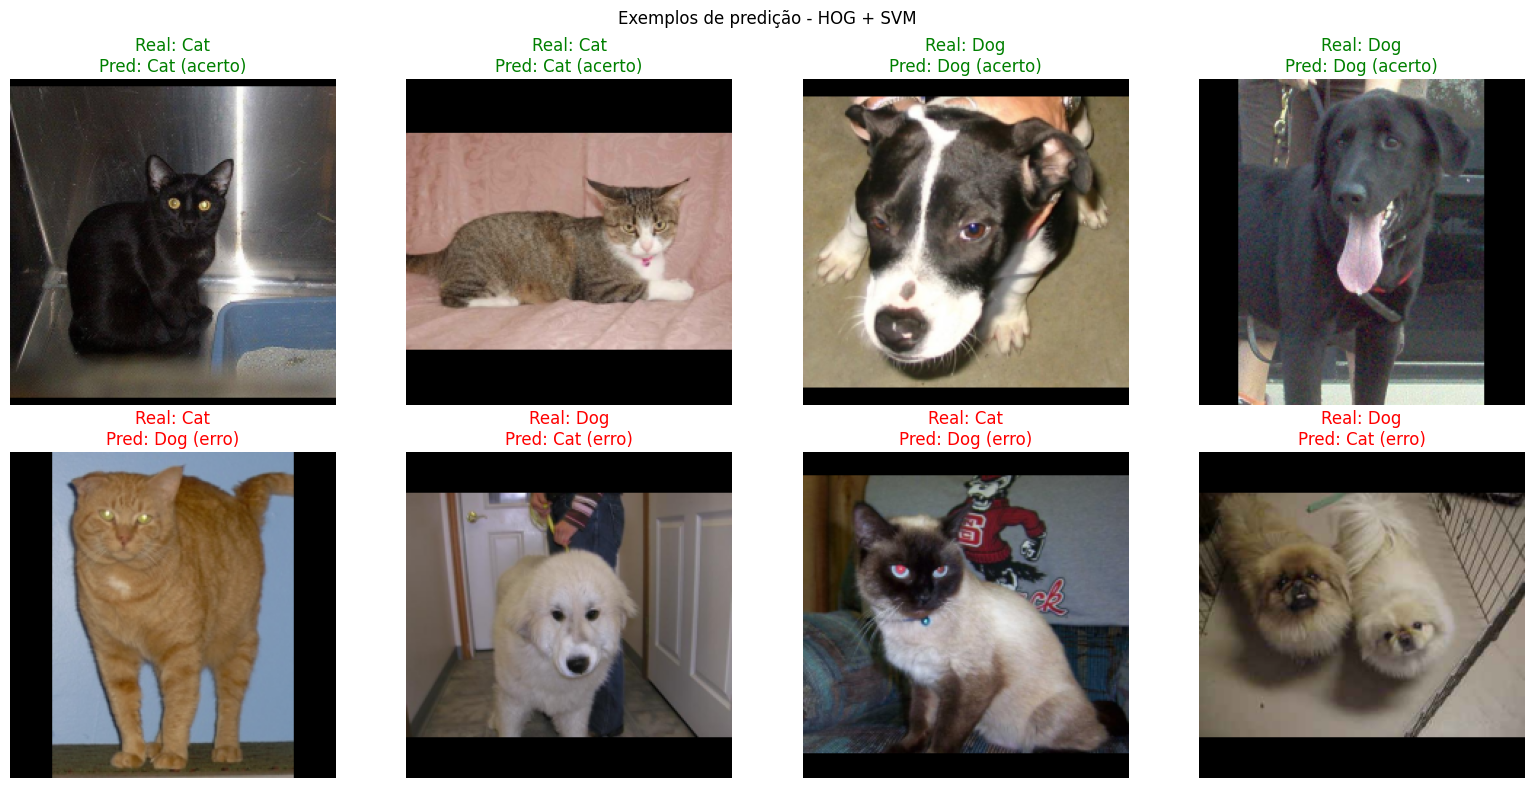

,path,class_name,pred_class,correct
0,PetImages/Cat/592.jpg,Cat,Cat,True
1,PetImages/Cat/7515.jpg,Cat,Cat,True
2,PetImages/Dog/4588.jpg,Dog,Dog,True
3,PetImages/Dog/4382.jpg,Dog,Dog,True
4,PetImages/Cat/8962.jpg,Cat,Dog,False
5,PetImages/Dog/4287.jpg,Dog,Cat,False
6,PetImages/Cat/3082.jpg,Cat,Dog,False
7,PetImages/Dog/2950.jpg,Dog,Cat,False


In [16]:
pred_df = test_df.copy()
pred_df["pred_label"] = test_pred
pred_df["pred_class"] = pred_df["pred_label"].map(LABEL_TO_CLASS)
pred_df["correct"] = pred_df["label"] == pred_df["pred_label"]

pieces = []
for class_name in CLASS_NAMES:
    subset = pred_df[(pred_df["class_name"] == class_name) & pred_df["correct"]]
    if len(subset):
        pieces.append(subset.sample(min(2, len(subset)), random_state=RANDOM_STATE))

wrong_subset = pred_df[~pred_df["correct"]]
if len(wrong_subset):
    pieces.append(wrong_subset.sample(min(4, len(wrong_subset)), random_state=RANDOM_STATE))

example_df = pd.concat(pieces).reset_index(drop=True)
example_df.to_csv(OUTPUT_DIR / "prediction_examples_hog_svm.csv", index=False)

cols = 4
rows = max(1, math.ceil(len(example_df) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.atleast_1d(axes).ravel()

for ax, (_, row) in zip(axes, example_df.iterrows()):
    ax.imshow(load_rgb_resized(row["path"]))
    color = "green" if row["correct"] else "red"
    status = "acerto" if row["correct"] else "erro"
    ax.set_title(f"Real: {row['class_name']}\nPred: {row['pred_class']} ({status})", color=color)
    ax.axis("off")

for ax in axes[len(example_df):]:
    ax.axis("off")

fig.suptitle("Exemplos de predição - HOG + SVM")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "prediction_examples_hog_svm.png", dpi=150, bbox_inches="tight")
plt.show()

display(example_df[["path", "class_name", "pred_class", "correct"]])

## 10. Arquivos gerados

Depois da execução completa, os principais resultados ficam em `outputs/partA/`:

- `metrics_hog_svm.csv`: acurácias, F1-score e configuração;
- `svm_c_tuning.csv`: resultados da validação para escolha de `C` quando `TUNE_SVM_C=True`;
- `classification_report_hog_svm.txt`: precision, recall e F1;
- `confusion_matrix_hog_svm.png`: matriz de confusão;
- `prediction_examples_hog_svm.png`: exemplos de acerto e erro;
- `hog_svm_opencv.xml`: modelo SVM treinado.